In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.4 anndata==0.11.1 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.0 igraph==0.11.5 pynndescent==0.5.12


In [11]:
N1= sc.read_h5ad('N1_subclass_ann.h5ad')
N2= sc.read_h5ad('N2_subclass_ann.h5ad')

In [34]:
adata = sc.AnnData.concatenate(N1,N2,batch_categories=('V1_N1','V1_N2'),batch_key='Sample')
adata.write_h5ad('./NR_merge.h5ad')

/var/folders/r4/hfj1yx3s3bd93mtgxzfwcfyc0000gn/T/ipykernel_53244/1003582453.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(N1,N2,batch_categories=('V1_N1','V1_N2'),batch_key='Sample')


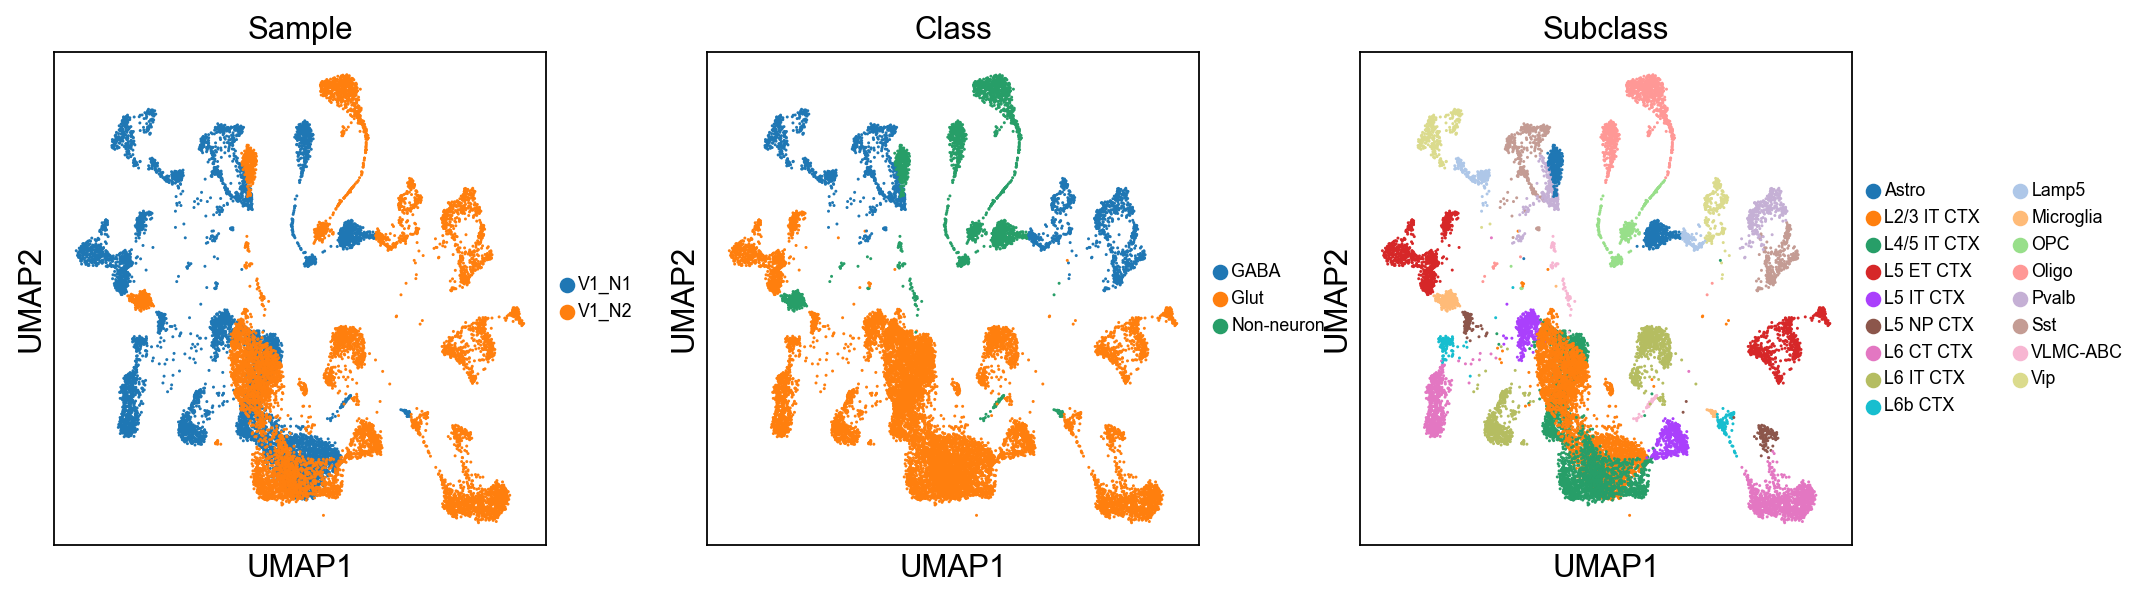

In [35]:
sc.pl.umap(
    adata,
    color=["Sample","Class","Subclass"],
    legend_fontsize=8
)

In [36]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5,flavor='seurat')

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [37]:
sc.set_figure_params(color_map='RdBu_r')
sc.tl.pca(adata, svd_solver='arpack',use_highly_variable=True)

computing PCA
    with n_comps=50


/opt/anaconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:01)


In [38]:
sc.pp.neighbors(adata, n_neighbors=20, use_rep='X_pca')
sc.tl.umap(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)


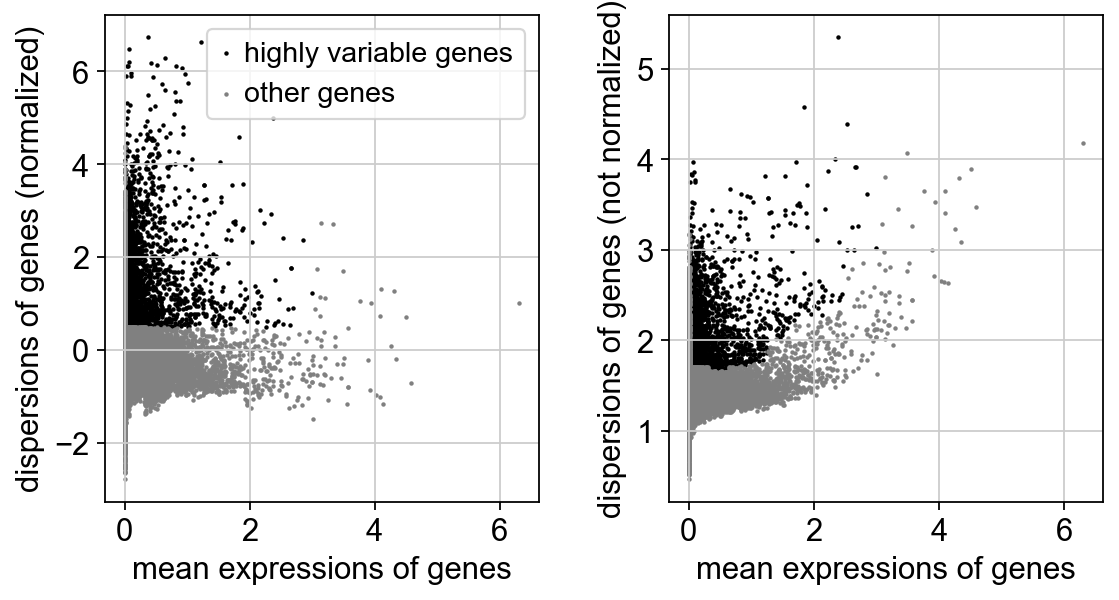

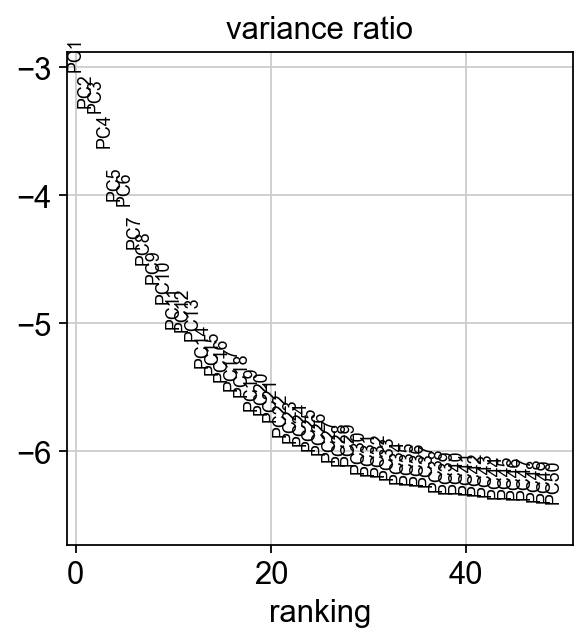

In [39]:
sc.pl.highly_variable_genes(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

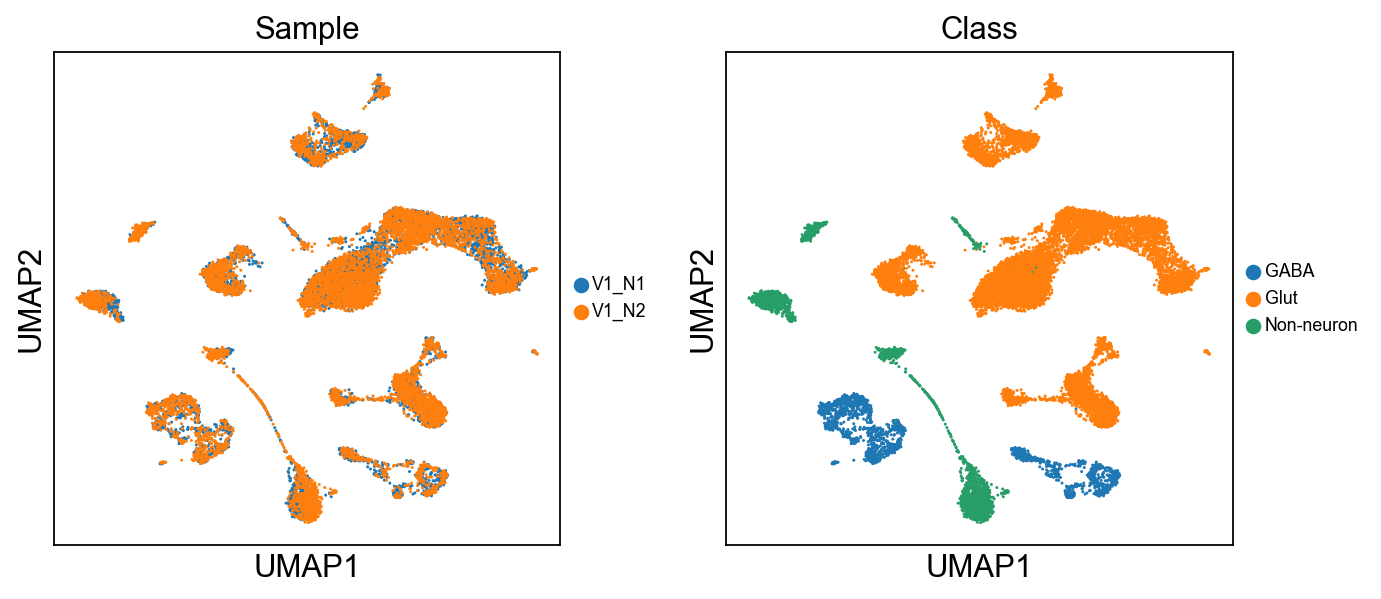

In [40]:
sc.pl.umap(
    adata,
    color=["Sample","Class"],
    legend_fontsize=8
)

In [44]:
adata.obs

,n_genes,percent_mito,n_counts,doublet_score,predicted_doublet,leiden_res_1.00,leiden_res_1.20,Class,presubclass,preclass,cluster,Subclass,Sample
AAACCCAAGTACTGTC-1-V1_N1,1003,0.0,1577.0,0.004434,False,0,0,GABA,Pvalb Gaba,CTX-MGE GABA,Pvalb,Pvalb,V1_N1
AAACCCAAGTTGGAAT-1-V1_N1,1334,0.0,2437.0,0.002663,False,1,1,Glut,L5 IT CTX Glut,IT-ET Glut,L5 IT CTX,L5 IT CTX,V1_N1
AAACCCACAGAAATTG-1-V1_N1,695,0.0,973.0,0.033153,False,2,2,Non-neuron,Astro-TE NN,Astro-Epen,Astro,Astro,V1_N1
AAACCCACATACCAGT-1-V1_N1,2176,0.0,4904.0,0.060674,False,3,3,Glut,L4/5 IT CTX Glut,IT-ET Glut,L4/5 IT CTX A,L4/5 IT CTX,V1_N1
AAACCCAGTCTACATG-1-V1_N1,2605,0.0,6867.0,0.042017,False,4,4,Glut,L5 ET CTX Glut,IT-ET Glut,L5 ET CTX A,L5 ET CTX,V1_N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCATGCCGG-1-V1_N2,2444,0.0,6378.0,0.066507,False,4,2,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N2
TTTGTTGTCCATACTT-1-V1_N2,605,0.0,890.0,0.013114,False,7,8,Non-neuron,Oligo NN,OPC-Oligo,Oligo A,Oligo,V1_N2
TTTGTTGTCGGCTGAC-1-V1_N2,1571,0.0,2859.0,0.068627,False,1,1,Glut,L4/5 IT CTX Glut,IT-ET Glut,L4/5 IT CTX A,L4/5 IT CTX,V1_N2
TTTGTTGTCTTGGATG-1-V1_N2,961,0.0,1578.0,0.005154,False,13,14,Non-neuron,Astro-TE NN,Astro-Epen,Astro,Astro,V1_N2


In [46]:
del adata.obs['leiden_res_1.00']
del adata.obs['leiden_res_1.20']


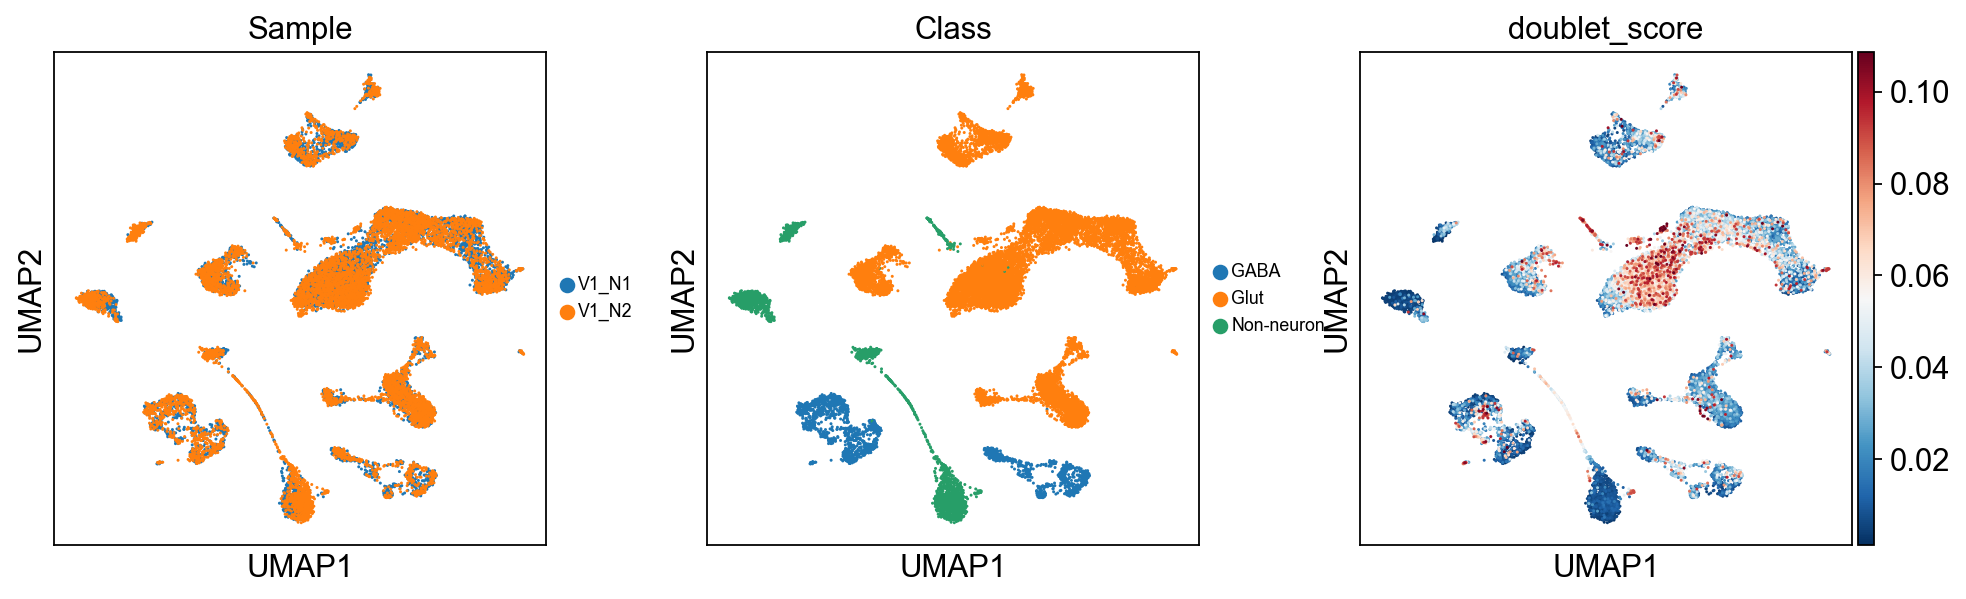

In [23]:
sc.pl.umap(
    adata,
    color=["Sample","Class","doublet_score"],
    legend_fontsize=8
)

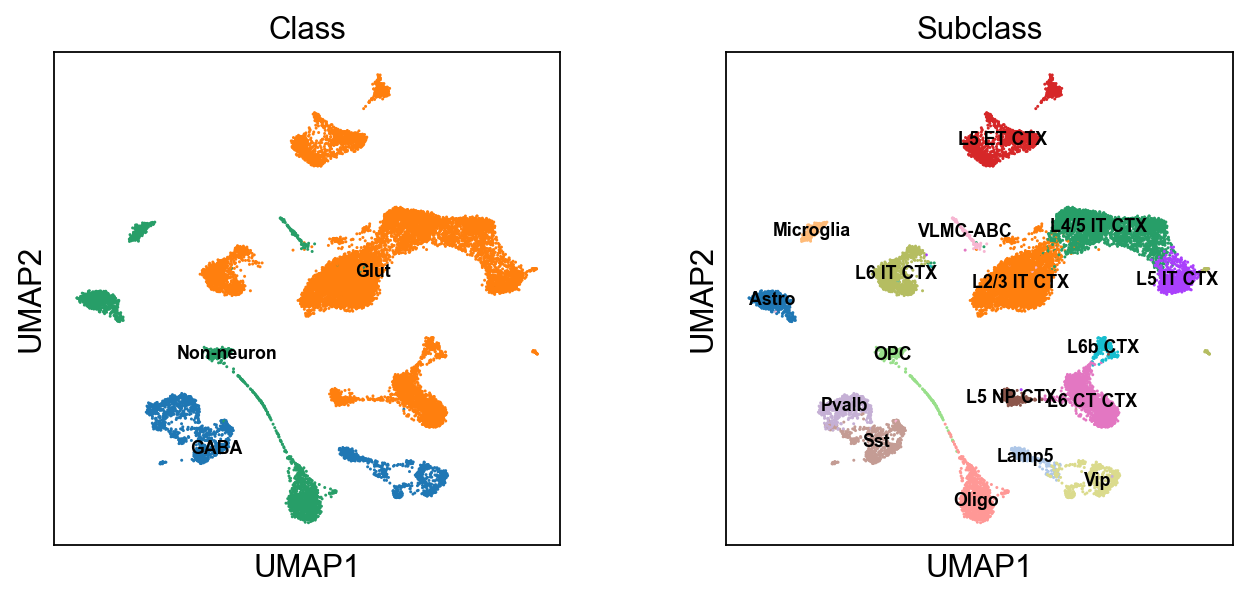

In [45]:
sc.pl.umap(
    adata,
    color=["Class","Subclass"],
    legend_fontsize=8,legend_loc="on data"
)

In [47]:
for res in [0.5,0.8,1,1.2]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

running Leiden clustering
    finished: found 20 clusters and added
    'leiden_res_0.50', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden_res_0.80', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 23 clusters and added
    'leiden_res_1.00', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 25 clusters and added
    'leiden_res_1.20', the cluster labels (adata.obs, categorical) (0:00:00)


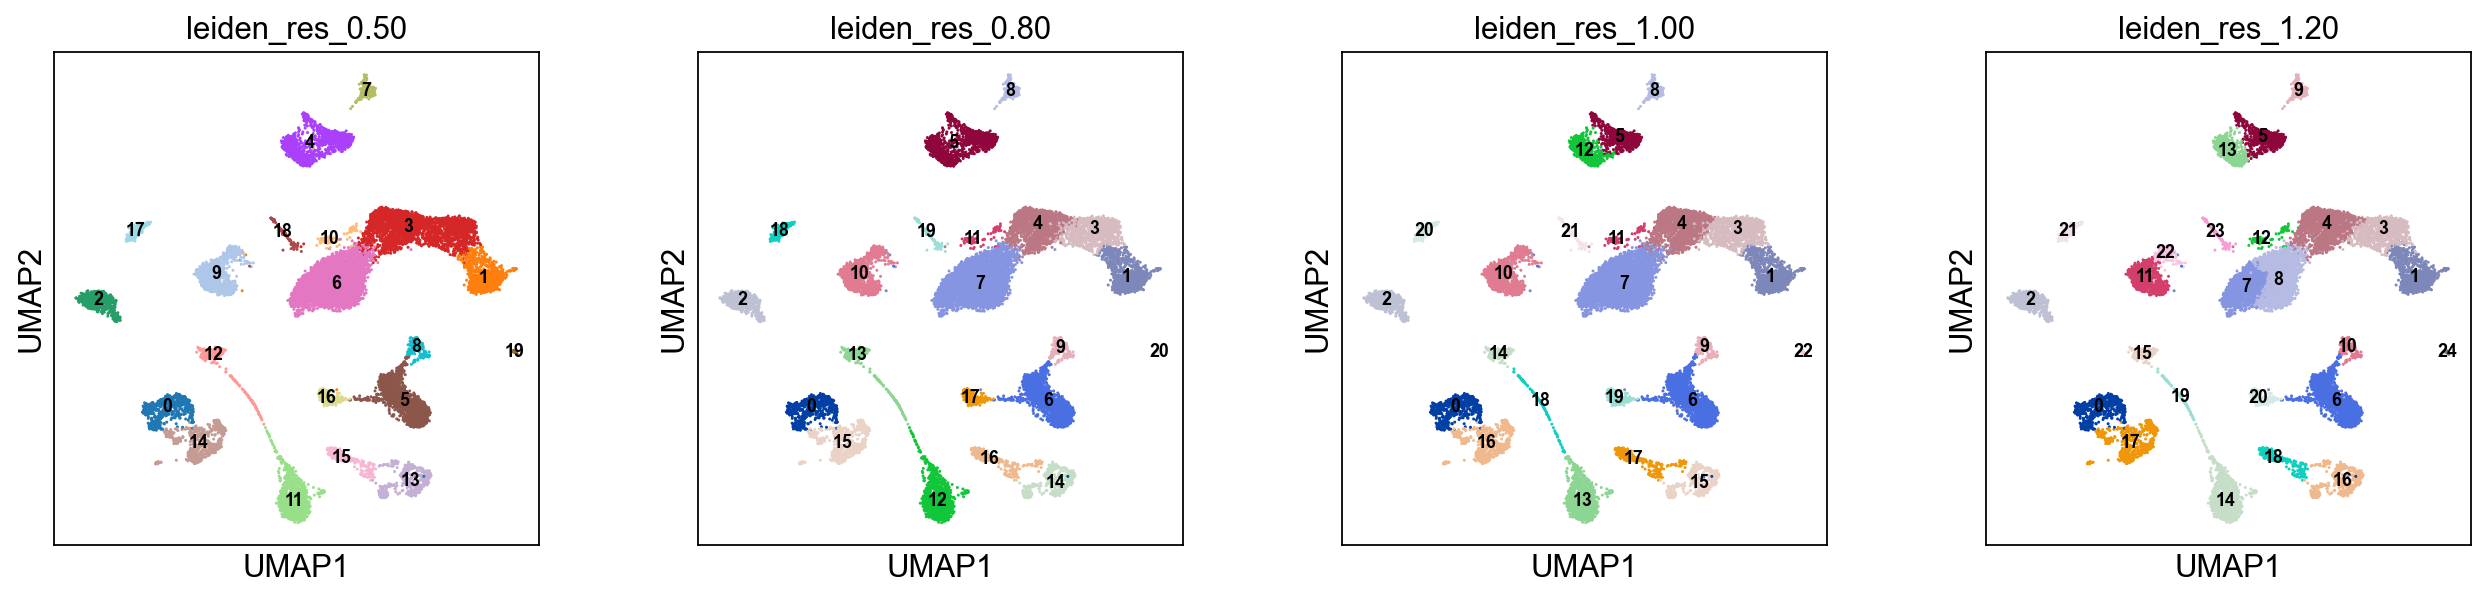

In [48]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.50", "leiden_res_0.80","leiden_res_1.00","leiden_res_1.20"],
    legend_loc="on data",legend_fontsize=8
)

In [49]:
adata.obs['leiden_res_1.00']

AAACCCAAGTACTGTC-1-V1_N1     0
AAACCCAAGTTGGAAT-1-V1_N1     1
AAACCCACAGAAATTG-1-V1_N1     2
AAACCCACATACCAGT-1-V1_N1     3
AAACCCAGTCTACATG-1-V1_N1     5
                            ..
TTTGTTGTCATGCCGG-1-V1_N2     7
TTTGTTGTCCATACTT-1-V1_N2    13
TTTGTTGTCGGCTGAC-1-V1_N2     4
TTTGTTGTCTTGGATG-1-V1_N2     2
TTTGTTGTCTTTACAC-1-V1_N2    10
Name: leiden_res_1.00, Length: 16612, dtype: category
Categories (23, object): ['0', '1', '2', '3', ..., '19', '20', '21', '22']

In [50]:
adata_f = adata[adata.obs['leiden_res_1.00'].isin (['0', '1', '2', '3','4','5','6','7','8','9','10','12','13','14','15','16','17','18', '19', '20', '21', '22']),:]

In [51]:
adata_f

View of AnnData object with n_obs × n_vars = 16522 × 22105
    obs: 'n_genes', 'percent_mito', 'n_counts', 'doublet_score', 'predicted_doublet', 'Class', 'presubclass', 'preclass', 'cluster', 'Subclass', 'Sample', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20'
    var: 'gene_ids', 'feature_types', 'n_cells-V1_N1', 'highly_variable-V1_N1', 'means-V1_N1', 'dispersions-V1_N1', 'dispersions_norm-V1_N1', 'n_cells-V1_N2', 'highly_variable-V1_N2', 'means-V1_N2', 'dispersions-V1_N2', 'dispersions_norm-V1_N2', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Sample_colors', 'Class_colors', 'Subclass_colors', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20', 'leiden_res_0.50_colors', 'leiden_res_0.80_colors', 'leiden_res_1.00_colors', 'leiden_res_1.20_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

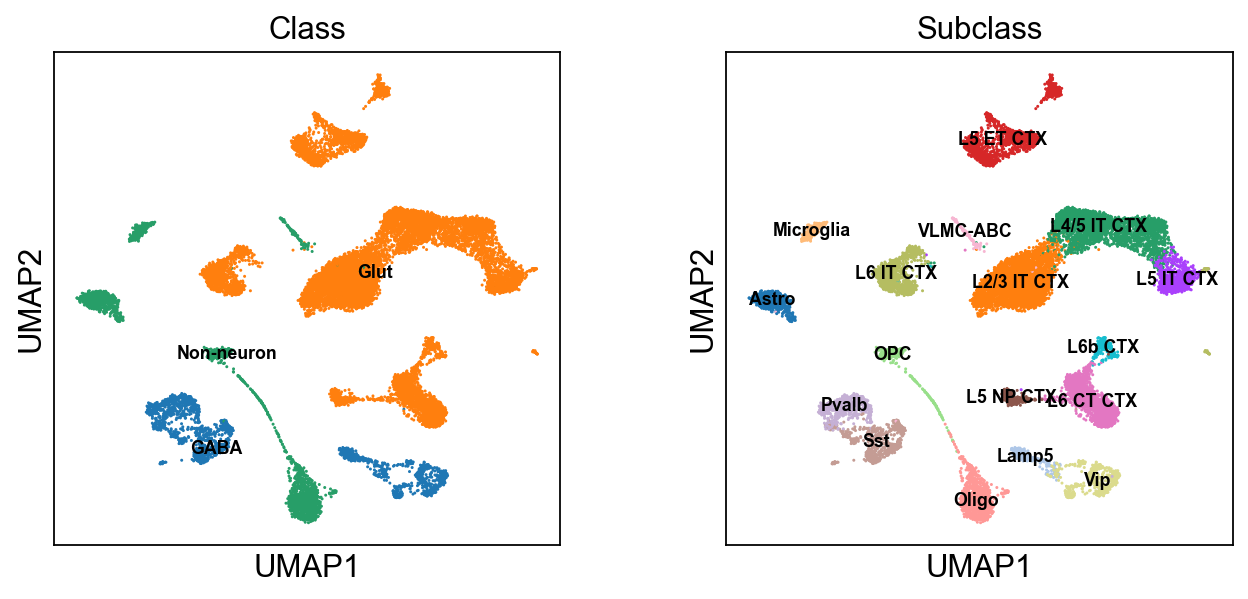

In [52]:
sc.pl.umap(
    adata_f,
    color=["Class","Subclass"],
    legend_fontsize=8,legend_loc="on data"
)

In [53]:
sc.pp.highly_variable_genes(adata_f, min_mean=0.0125, max_mean=3, min_disp=0.5,flavor='seurat')

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/opt/anaconda3/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:664: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [54]:
sc.set_figure_params(color_map='RdBu_r')
sc.tl.pca(adata_f, svd_solver='arpack',use_highly_variable=True)

computing PCA
    with n_comps=50


/opt/anaconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:01)


In [55]:
sc.pp.neighbors(adata_f, n_neighbors=20, use_rep='X_pca')
sc.tl.umap(adata_f)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)


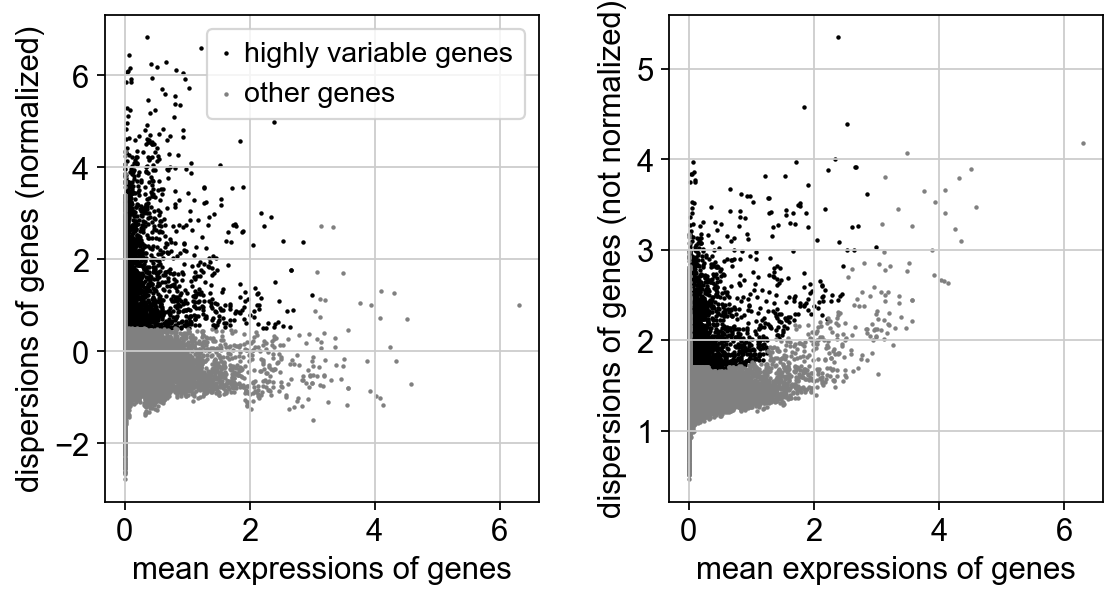

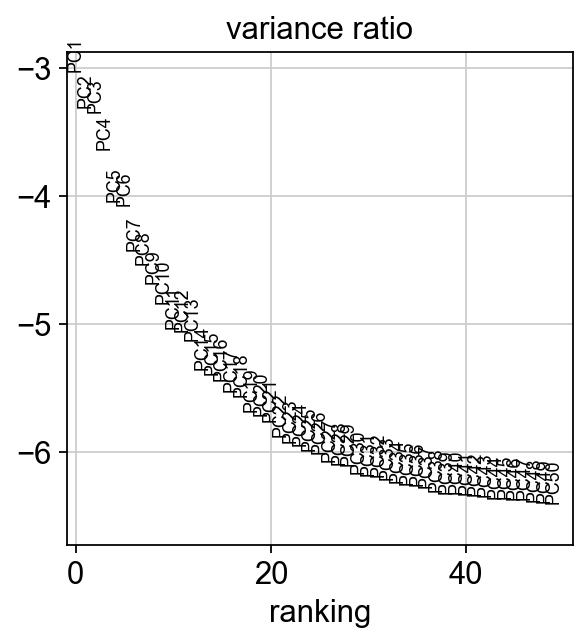

In [56]:
sc.pl.highly_variable_genes(adata_f)
sc.pl.pca_variance_ratio(adata_f, n_pcs=50, log=True)

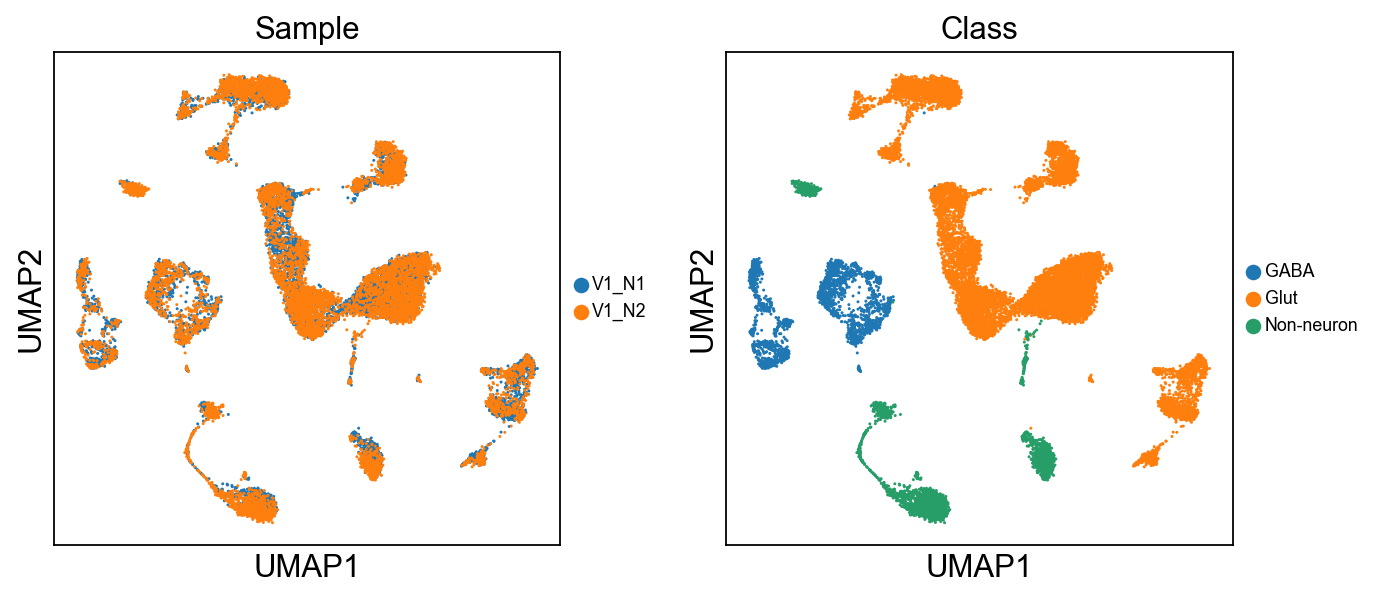

In [57]:
sc.pl.umap(
    adata_f,
    color=["Sample","Class"],
    legend_fontsize=8
)

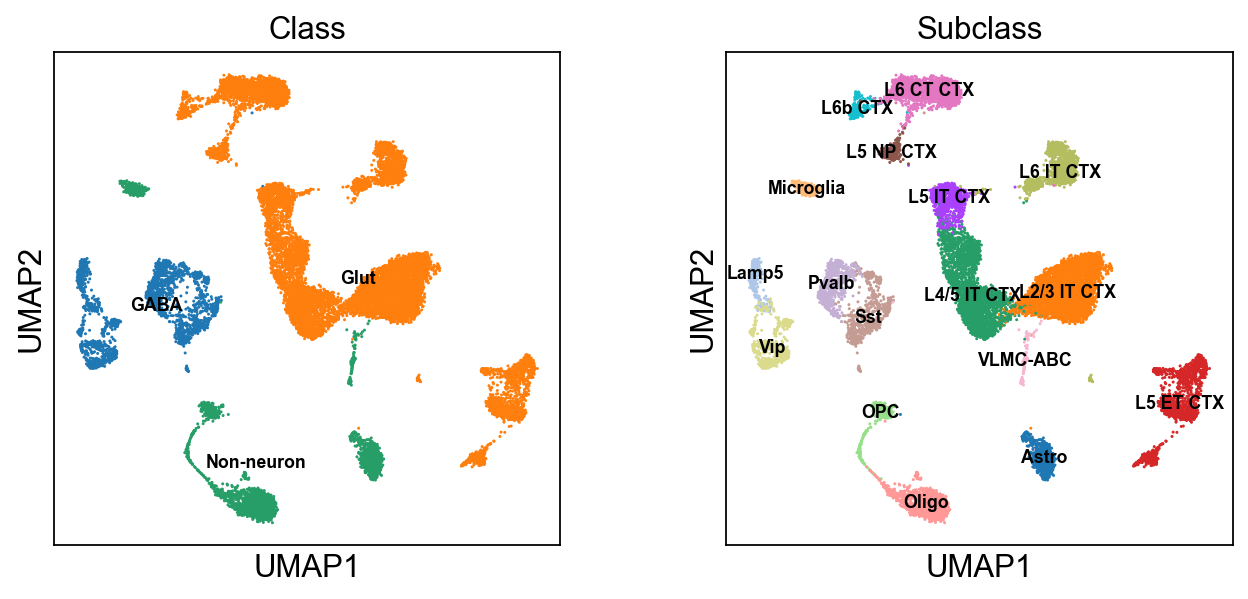

In [58]:
sc.pl.umap(
    adata_f,
    color=["Class","Subclass"],
    legend_fontsize=8,legend_loc="on data"
)

In [59]:
adata_f.write_h5ad('./NR_merge_ann.h5ad')

In [60]:
from collections import Counter

count = Counter(sorted(list(adata_f.obs['Subclass'])))
for k,v in count.items():
    print(k,v)

Astro 696
L2/3 IT CTX 3689
L4/5 IT CTX 2771
L5 ET CTX 1462
L5 IT CTX 777
L5 NP CTX 243
L6 CT CTX 1683
L6 IT CTX 1085
L6b CTX 219
Lamp5 315
Microglia 278
OPC 382
Oligo 995
Pvalb 600
Sst 661
VLMC-ABC 114
Vip 552


In [61]:
adata_f

AnnData object with n_obs × n_vars = 16522 × 22105
    obs: 'n_genes', 'percent_mito', 'n_counts', 'doublet_score', 'predicted_doublet', 'Class', 'presubclass', 'preclass', 'cluster', 'Subclass', 'Sample', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20'
    var: 'gene_ids', 'feature_types', 'n_cells-V1_N1', 'highly_variable-V1_N1', 'means-V1_N1', 'dispersions-V1_N1', 'dispersions_norm-V1_N1', 'n_cells-V1_N2', 'highly_variable-V1_N2', 'means-V1_N2', 'dispersions-V1_N2', 'dispersions_norm-V1_N2', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Sample_colors', 'Class_colors', 'Subclass_colors', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20', 'leiden_res_0.50_colors', 'leiden_res_0.80_colors', 'leiden_res_1.00_colors', 'leiden_res_1.20_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [62]:
l23 = adata_f[adata_f.obs['Subclass'] == 'L2/3 IT CTX',:]

In [63]:
l23

View of AnnData object with n_obs × n_vars = 3689 × 22105
    obs: 'n_genes', 'percent_mito', 'n_counts', 'doublet_score', 'predicted_doublet', 'Class', 'presubclass', 'preclass', 'cluster', 'Subclass', 'Sample', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20'
    var: 'gene_ids', 'feature_types', 'n_cells-V1_N1', 'highly_variable-V1_N1', 'means-V1_N1', 'dispersions-V1_N1', 'dispersions_norm-V1_N1', 'n_cells-V1_N2', 'highly_variable-V1_N2', 'means-V1_N2', 'dispersions-V1_N2', 'dispersions_norm-V1_N2', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Sample_colors', 'Class_colors', 'Subclass_colors', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20', 'leiden_res_0.50_colors', 'leiden_res_0.80_colors', 'leiden_res_1.00_colors', 'leiden_res_1.20_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

/opt/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


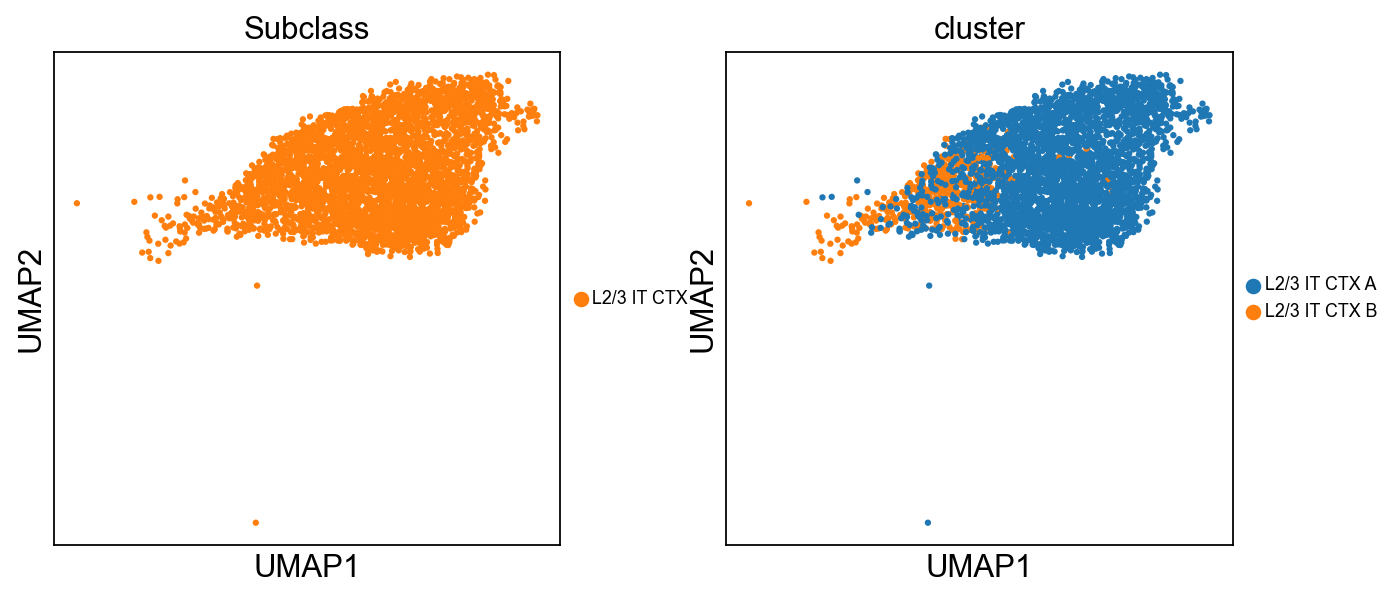

In [64]:
sc.pl.umap(
    l23,
    color=["Subclass","cluster"],
    legend_fontsize=8
)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50


/opt/anaconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


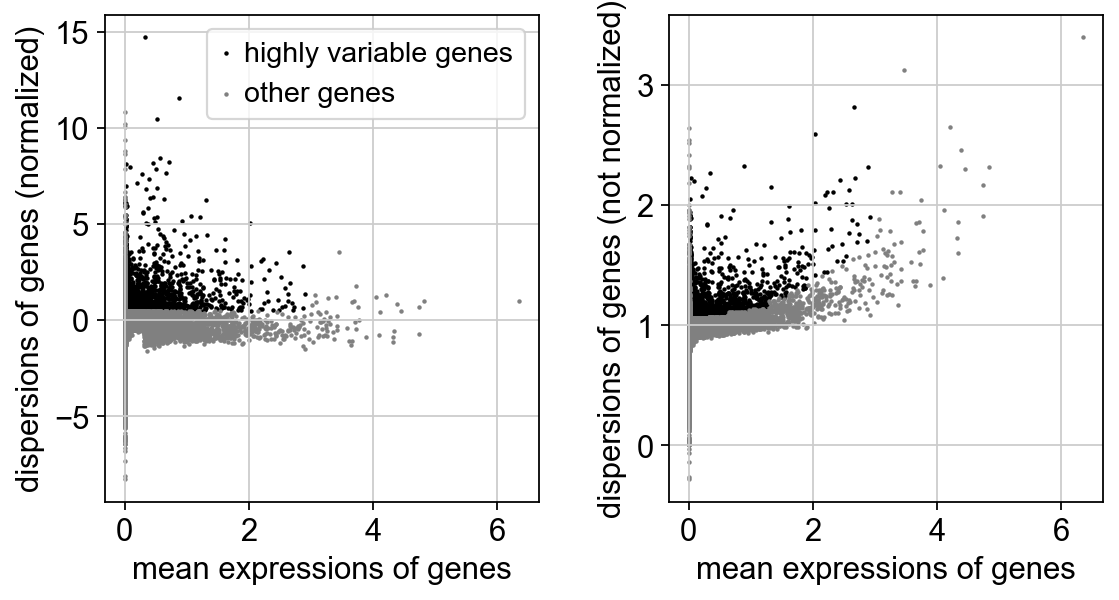

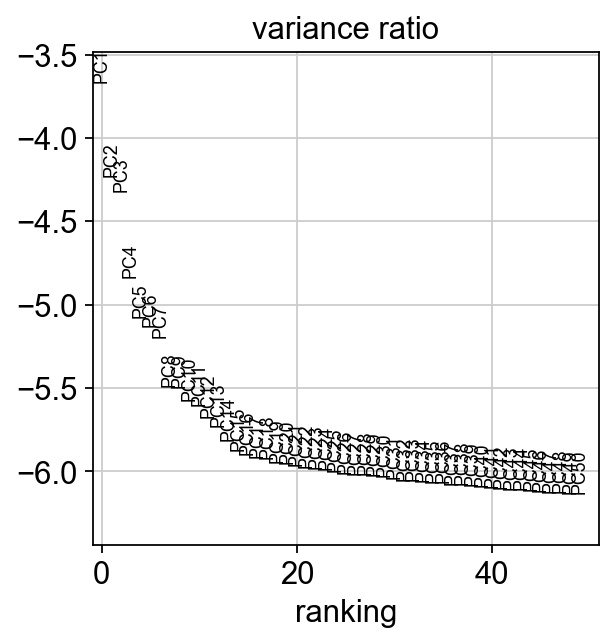

In [65]:
sc.pp.highly_variable_genes(l23, min_mean=0.0125, max_mean=3, min_disp=0.5,flavor='seurat')
sc.set_figure_params(color_map='RdBu_r')
sc.tl.pca(l23, svd_solver='arpack',use_highly_variable=True)
sc.pp.neighbors(l23, n_neighbors=20, use_rep='X_pca')
sc.tl.umap(l23)
sc.pl.highly_variable_genes(l23)
sc.pl.pca_variance_ratio(l23, n_pcs=50, log=True)

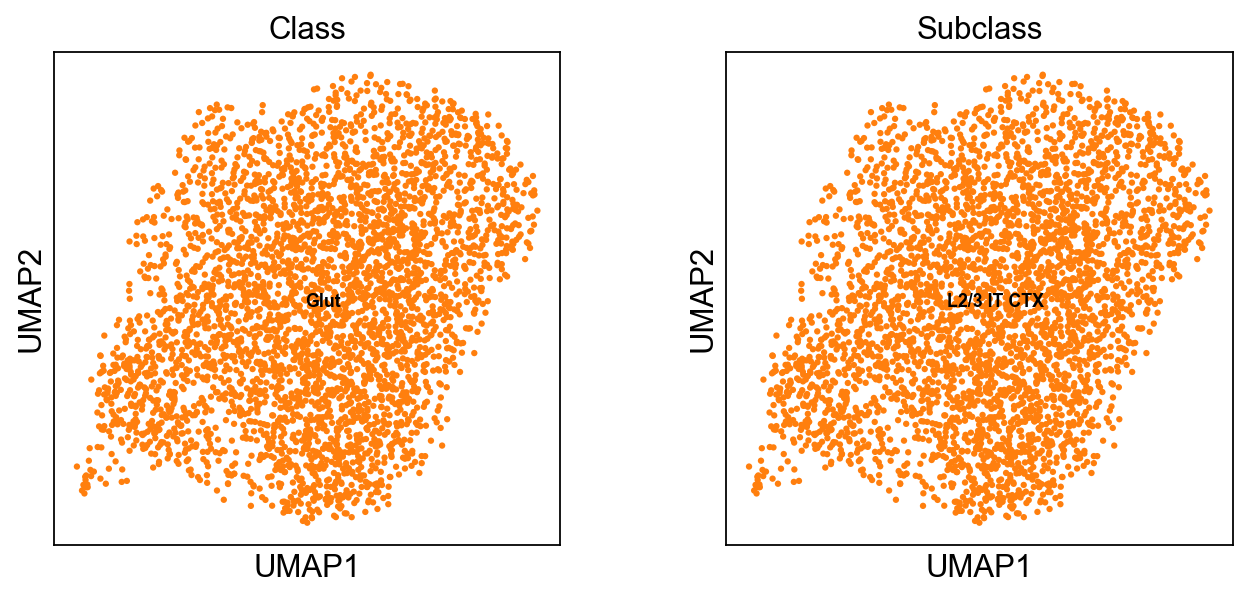

In [66]:
sc.pl.umap(
    l23,
    color=["Class","Subclass"],
    legend_fontsize=8,legend_loc="on data"
)

In [73]:
l23.obs

,n_genes,percent_mito,n_counts,doublet_score,predicted_doublet,Class,presubclass,preclass,cluster,Subclass,Sample
AAACCCATCGTTCATT-1-V1_N1,1610,0.0,3072.0,0.050949,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N1
AAACGCTCATGCCATA-1-V1_N1,1969,0.0,4156.0,0.058888,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX B,L2/3 IT CTX,V1_N1
AAAGAACAGACCCTTA-1-V1_N1,1668,0.0,3562.0,0.034921,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N1
AAAGAACAGGTCACAG-1-V1_N1,1458,0.0,2669.0,0.016873,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N1
AAAGAACCATTAGGCT-1-V1_N1,1318,0.0,2525.0,0.024358,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N1
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGCACACAG-1-V1_N2,2099,0.0,4539.0,0.060674,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N2
TTTGTTGAGGTGCGAT-1-V1_N2,2015,0.0,4388.0,0.062536,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N2
TTTGTTGCACGAGAAC-1-V1_N2,2215,0.0,4914.0,0.100408,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N2
TTTGTTGGTGCGGTAA-1-V1_N2,1531,0.0,3283.0,0.049534,False,Glut,L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX A,L2/3 IT CTX,V1_N2


In [70]:
del l23.obs['leiden_res_0.80']
del l23.obs['leiden_res_1.00']
del l23.obs['leiden_res_1.20']
del l23.obs['leiden_res_0.20']
del l23.obs['leiden_res_0.60']
del l23.obs['leiden_res_0.70']

In [72]:
del l23.obs['leiden_res_0.50']

In [74]:
for res in [0.2,0.3,0.5,0.6]:
    sc.tl.leiden(
        l23, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

running Leiden clustering
    finished: found 1 clusters and added
    'leiden_res_0.20', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 2 clusters and added
    'leiden_res_0.30', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden_res_0.50', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 5 clusters and added
    'leiden_res_0.60', the cluster labels (adata.obs, categorical) (0:00:00)


In [76]:
sc.tl.leiden(l23, key_added="leiden_res_0.4", resolution=0.4, flavor="igraph")

running Leiden clustering
    finished: found 2 clusters and added
    'leiden_res_0.4', the cluster labels (adata.obs, categorical) (0:00:00)


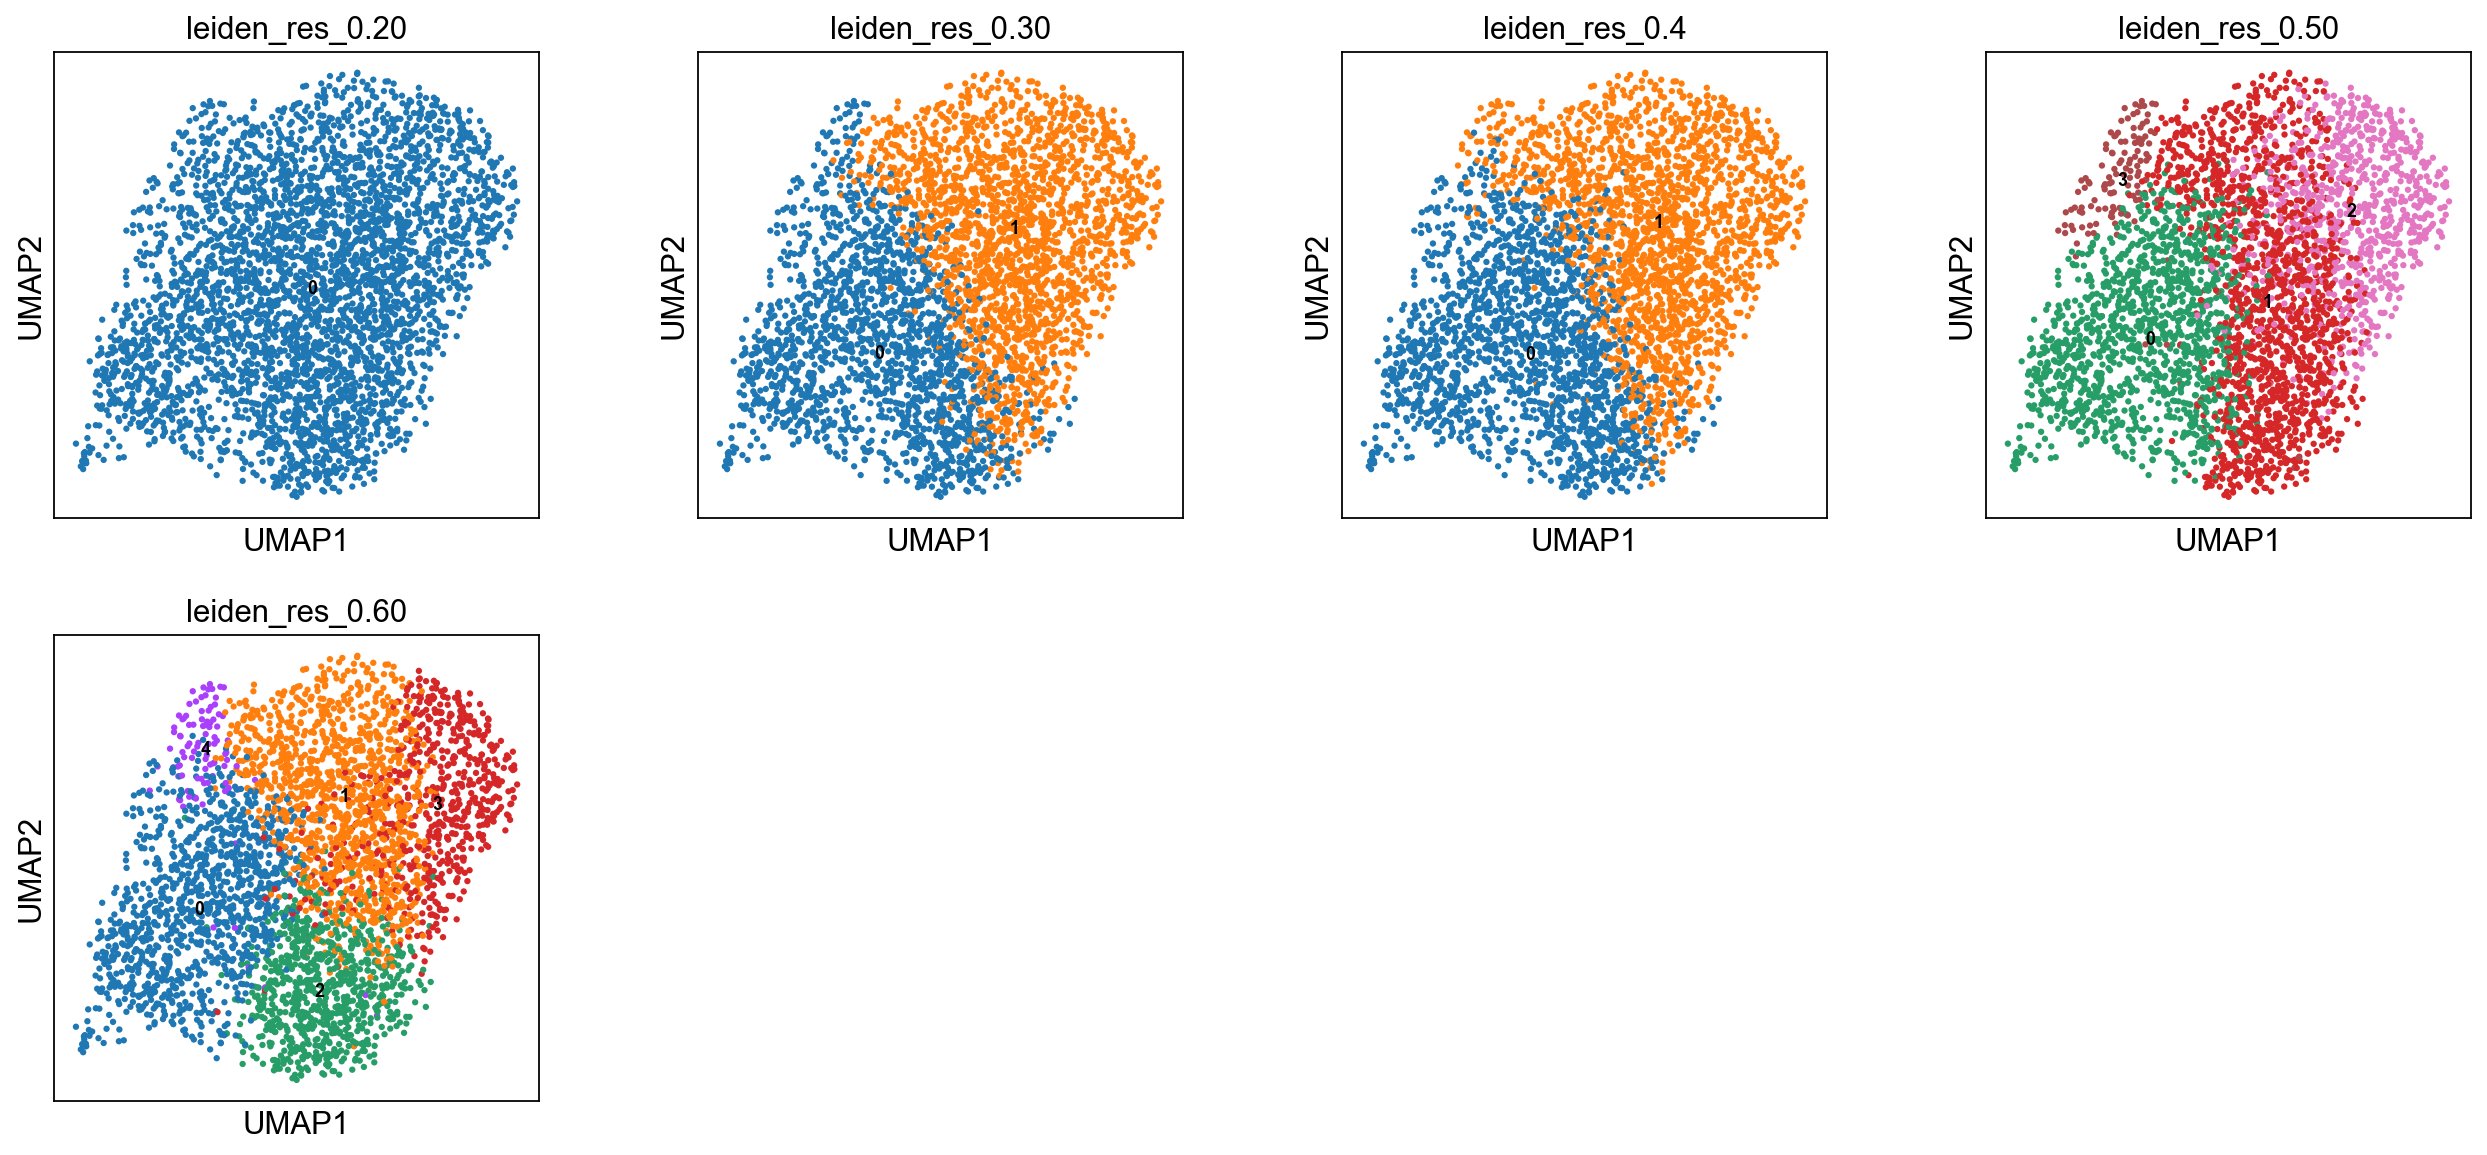

In [79]:
sc.pl.umap(
    l23,
    color=["leiden_res_0.20", "leiden_res_0.30","leiden_res_0.4","leiden_res_0.50","leiden_res_0.60"],
    legend_loc="on data",legend_fontsize=8
)

In [2]:
adata = sc.read_h5ad('./NR_merge_ann.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 16522 × 22105
    obs: 'n_genes', 'percent_mito', 'n_counts', 'doublet_score', 'predicted_doublet', 'Class', 'presubclass', 'preclass', 'cluster', 'Subclass', 'Sample', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20'
    var: 'gene_ids', 'feature_types', 'n_cells-V1_N1', 'highly_variable-V1_N1', 'means-V1_N1', 'dispersions-V1_N1', 'dispersions_norm-V1_N1', 'n_cells-V1_N2', 'highly_variable-V1_N2', 'means-V1_N2', 'dispersions-V1_N2', 'dispersions_norm-V1_N2', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Class_colors', 'Sample_colors', 'Subclass_colors', 'hvg', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'leiden_res_0.80', 'leiden_res_0.80_colors', 'leiden_res_1.00', 'leiden_res_1.00_colors', 'leiden_res_1.20', 'leiden_res_1.20_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

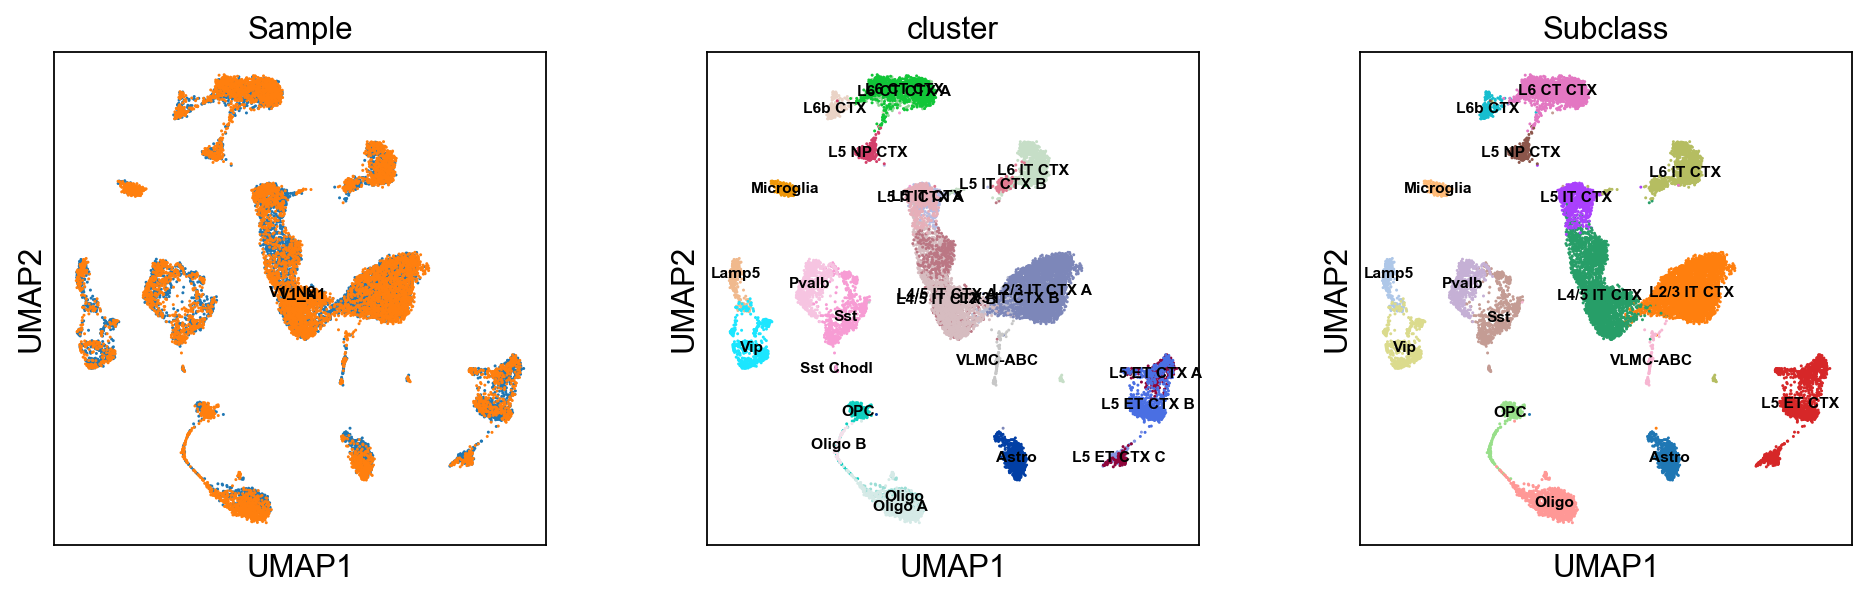

In [5]:
sc.pl.umap(
    adata,
    color=["Sample","cluster","Subclass"],
    legend_loc="on data",legend_fontsize=7
)

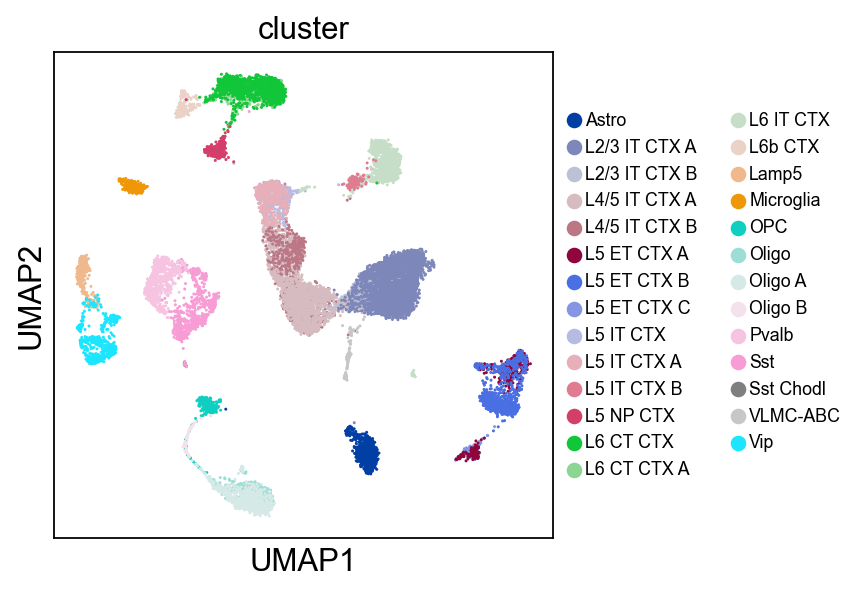

In [6]:
sc.pl.umap(
    adata,
    color="cluster",
    legend_fontsize=8
)

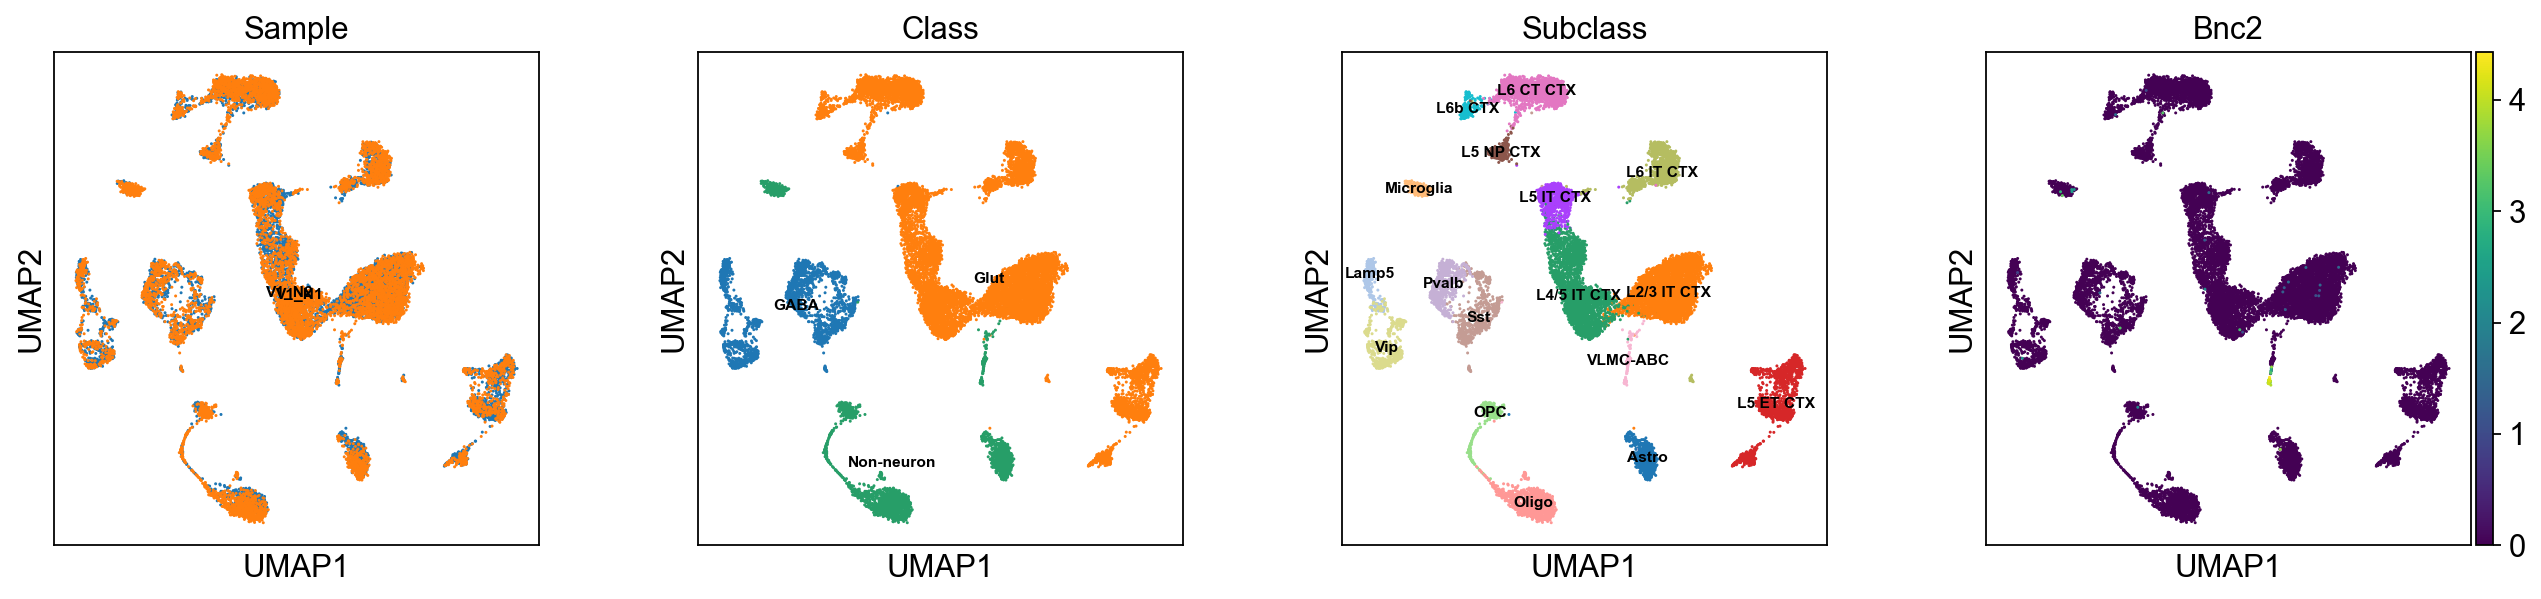

In [5]:
sc.pl.umap(
    adata,
    color=["Sample","Class","Subclass","Bnc2"],
    legend_loc="on data",legend_fontsize=7
)

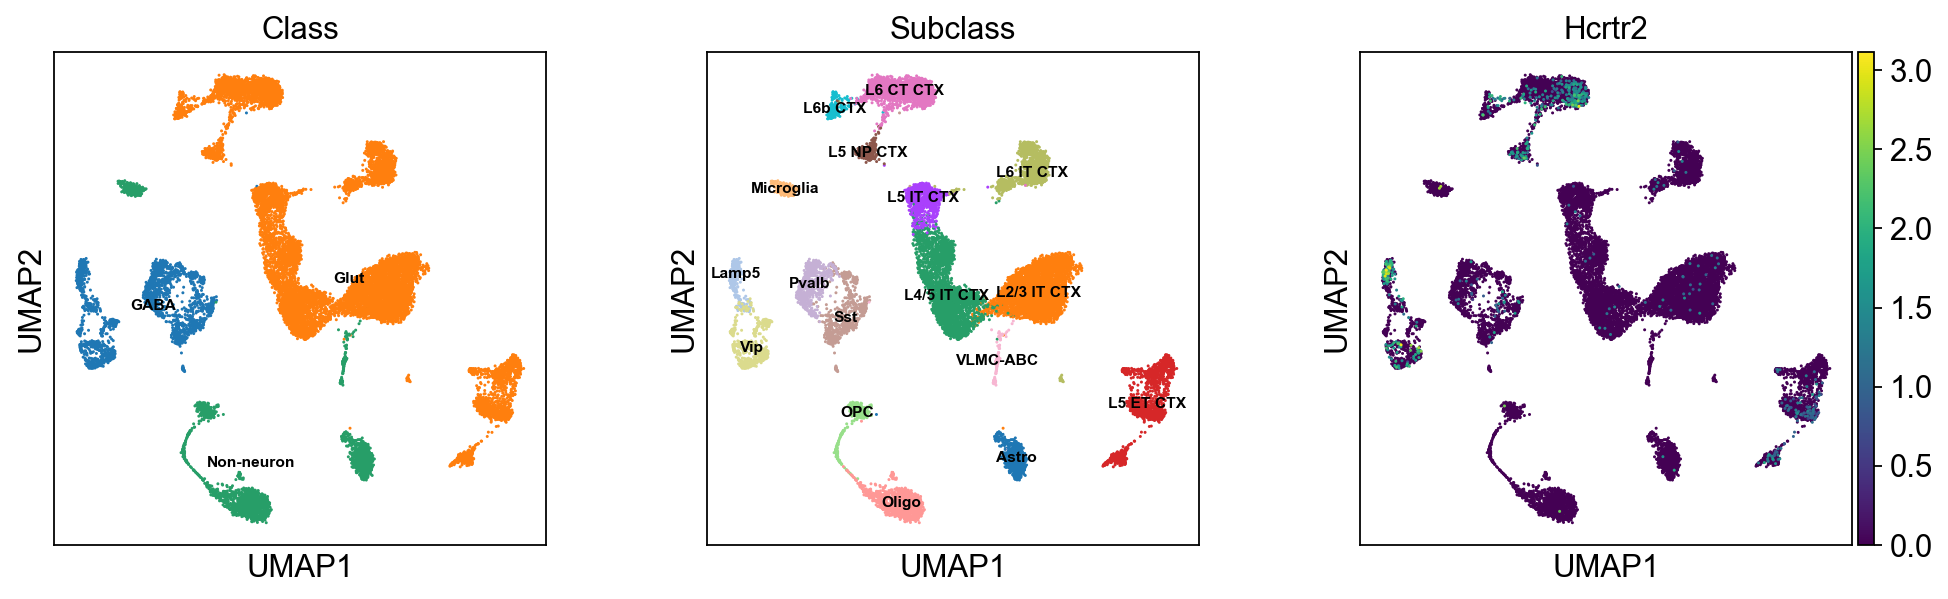

In [3]:
sc.pl.umap(
    adata,
    color=["Class","Subclass","Hcrtr2"],
    legend_loc="on data",legend_fontsize=7
)

In [4]:
adata

AnnData object with n_obs × n_vars = 16522 × 22105
    obs: 'n_genes', 'percent_mito', 'n_counts', 'doublet_score', 'predicted_doublet', 'Class', 'presubclass', 'preclass', 'cluster', 'Subclass', 'Sample', 'leiden_res_0.50', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.20'
    var: 'gene_ids', 'feature_types', 'n_cells-V1_N1', 'highly_variable-V1_N1', 'means-V1_N1', 'dispersions-V1_N1', 'dispersions_norm-V1_N1', 'n_cells-V1_N2', 'highly_variable-V1_N2', 'means-V1_N2', 'dispersions-V1_N2', 'dispersions_norm-V1_N2', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Class_colors', 'Sample_colors', 'Subclass_colors', 'hvg', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'leiden_res_0.80', 'leiden_res_0.80_colors', 'leiden_res_1.00', 'leiden_res_1.00_colors', 'leiden_res_1.20', 'leiden_res_1.20_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'